In [ ]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sc_toolbox as sct

[rank: 0] Global seed set to 0


In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)

In [ ]:
adata_list = []
for sample in ['R5779_TMA2-S6', 'R5779_TMA3-S4']:
    adata = sq.read.nanostring(
        path=f'/projects/0/einf2548/cruiz/dmg/ST/SMI-0262_Broek.Vuurden_PrinsesMaxima-selected/5 Raw data/{sample}', 
        counts_file=f'{sample}_exprMat_file.csv',
        meta_file=f'{sample}_metadata_file.csv',
        fov_file=f'{sample}_fov_positions_file.csv'
    )

    # Flip y axis
    adata.obsm['spatial_fov'][:, 1] = np.max(adata.obsm['spatial_fov'][:, 1]) - adata.obsm['spatial_fov'][:, 1]

    # Remove negative probes
    adata = adata[:, [c for c in adata.var_names if 'NegPrb' not in c]].copy()
    
    adata.obs['sample'] = sample
    adata_list.append(adata)

In [ ]:
adata = ad.concat(adata_list, axis=0, merge='same', pairwise=True, index_unique='_')

# 'spatial_fov' refers to global coordinates of the cells.
# Thus, we are going to use 'spatial_fov' and not 'spatial' as spatial coordinates.
adata.uns['spatial_fov'] = {s: {} for s in adata.obs['sample'].unique()}
adata.obs['sample'] = pd.Categorical(adata.obs['sample'])
adata

AnnData object with n_obs × n_vars = 67280 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample'
    uns: 'spatial_fov'
    obsm: 'spatial', 'spatial_fov'

In [ ]:
adata.obs['sample2'] = adata.obs['sample'].str.replace('_', '.')

# Create a new index by combining 'sample' column and the current index
adata.obs.index = adata.obs['sample2'] + '_' + adata.obs.index

# Strip the part after the last underscore in the new index
adata.obs.index = adata.obs.index.str.rsplit('_', n=1).str[0]

In [ ]:
matching_indexes = adata.obs.index.intersection(metadata_df.index)

In [ ]:
adata = adata[matching_indexes].copy()
adata

AnnData object with n_obs × n_vars = 26552 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2'
    uns: 'spatial_fov'
    obsm: 'spatial', 'spatial_fov'

In [ ]:
for column in metadata_df.columns:
    if column not in adata.obs.columns:
        adata.obs[column] = metadata_df[column]
adata.obs

,fov,Area,AspectRatio,CenterX_global_px,CenterY_global_px,Width,Height,Mean.Histone,Max.Histone,Mean.G,...,Run_Tissue_name,log10totalcounts,IFcolor,nb_clus,leiden_clus,id,FOV,PMCID,Replicate,ID_R
R5779.TMA2-S6_1_6,6,13541,2.06,-91818.593928,24598.076074,196,95,1574,14424,24,...,R5779_TMA2-S6,2.394452,#8E463CFF,j,8,R5779.TMA2-S6_1_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4
R5779.TMA2-S6_2_6,6,9866,1.49,-90783.593928,24597.076074,145,97,2271,22200,24,...,R5779_TMA2-S6,2.608526,#816562FF,j,8,R5779.TMA2-S6_2_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4
R5779.TMA2-S6_3_6,6,11085,1.44,-91065.593928,24595.076074,147,102,705,4696,10,...,R5779_TMA2-S6,2.820858,#BA1F5EFF,j,8,R5779.TMA2-S6_3_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4
R5779.TMA2-S6_4_6,6,6931,0.98,-94113.593928,24577.076074,107,109,2350,8616,4,...,R5779_TMA2-S6,2.382017,#366959FF,j,8,R5779.TMA2-S6_4_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4
R5779.TMA2-S6_5_6,6,10243,1.22,-91193.593928,24552.076074,151,124,3616,14776,20,...,R5779_TMA2-S6,2.764176,#27A153FF,j,8,R5779.TMA2-S6_5_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R5779.TMA3-S4_778_25,25,19899,1.47,204602.133870,53655.446082,187,127,870,11064,69,...,R5779_TMA3-S4,2.267172,#FF2721FF,c,2,R5779.TMA3-S4_778_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3
R5779.TMA3-S4_779_25,25,7369,1.75,204048.133870,53630.446082,135,77,547,3332,74,...,R5779_TMA3-S4,2.184691,#FF182CFF,d,3,R5779.TMA3-S4_779_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3
R5779.TMA3-S4_780_25,25,18654,1.90,204800.133870,53649.446082,219,115,285,13832,50,...,R5779_TMA3-S4,2.350248,#FF0D07FF,d,3,R5779.TMA3-S4_780_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3
R5779.TMA3-S4_781_25,25,2768,2.58,205791.133870,53611.446082,98,38,954,8520,12,...,R5779_TMA3-S4,1.397940,#FF2B05FF,c,1,R5779.TMA3-S4_781_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3


In [ ]:
sc.pp.filter_genes(adata, min_counts=3)
sc.pp.filter_cells(adata, min_counts=3)

In [ ]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
scvi.settings.seed = 12345
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts", 
    batch_key='PMCID'
)

model = scvi.model.SCVI(adata)

[rank: 0] Global seed set to 12345
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [ ]:
model.train(early_stopping=True, enable_progress_bar=True)

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(


Epoch 1/301:   0%|                                                                                           | 0/301 [00:00<?, ?it/s]

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


Epoch 301/301: 100%|████████████████████████████████████████████████████████████| 301/301 [08:20<00:00,  1.66s/it, loss=495, v_num=1]


In [ ]:
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)

In [ ]:
adata.obs['sample'] = pd.Categorical(adata.obs['sample'])
sq.gr.spatial_neighbors(adata, library_key='sample', coord_type='generic', delaunay=True, spatial_key='spatial_fov')
cc.gr.remove_long_links(adata)

In [ ]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='fov')

  0%|          | 0/21 [00:00<?, ?it/s]

In [ ]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,20), 
    max_runs=10, 
    model_params=dict(
        random_state=12345,
        # If running on GPU
        trainer_params=dict(accelerator='gpu', devices=1)
    )
)

In [ ]:
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/10


  0%|          | 0/21 [00:00<?, ?it/s]

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used.

Iteration 2/10


  0%|          | 0/21 [00:00<?, ?it/s]

...

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used.

Iteration 9/10


  0%|          | 0/21 [00:00<?, ?it/s]

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used.

Convergence with a change in stability of 0.008810354033482832 reached after 9 iterations


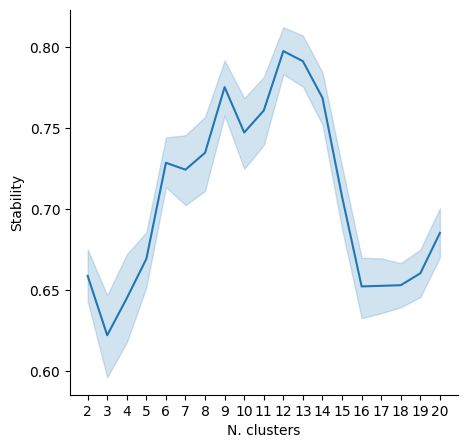

In [ ]:
cc.pl.autok_stability(autok)

In [ ]:
adata.obs['cluster_cellcharter'] = autok.predict(adata, use_rep='X_cellcharter')

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(


In [ ]:
slide1 = sc.read('../data/tangram_R5779_TMA2-S6_FINAL.h5ad')
slide2 = sc.read('../data/tangram_R5779_TMA3-S4_FINAL.h5ad')

In [ ]:
slide1.obs

,fov,Area,AspectRatio,CenterX_global_px,CenterY_global_px,Width,Height,Mean.Histone,Max.Histone,Mean.G,...,PMCID,Replicate,ID_R,uniform_density,rna_count_based_density,x,y,tangram_prediction,tangram_score,leiden
R5779.TMA2-S6_1_6,6,13541,2.06,-91818.593928,24598.076074,196,95,1574,14424,24,...,PMCID448AAQ,R4,PMCID448AAQ_R4,0.000243,0.000218,3095,42,TD_like,0.417731,2
R5779.TMA2-S6_2_6,6,9866,1.49,-90783.593928,24597.076074,145,97,2271,22200,24,...,PMCID448AAQ,R4,PMCID448AAQ_R4,0.000243,0.000274,4130,43,OPC_like,0.469717,3
R5779.TMA2-S6_3_6,6,11085,1.44,-91065.593928,24595.076074,147,102,705,4696,10,...,PMCID448AAQ,R4,PMCID448AAQ_R4,0.000243,0.000315,3848,45,Cilia_like,0.847367,2
R5779.TMA2-S6_4_6,6,6931,0.98,-94113.593928,24577.076074,107,109,2350,8616,4,...,PMCID448AAQ,R4,PMCID448AAQ_R4,0.000243,0.000196,800,63,RG_like,0.612234,1
R5779.TMA2-S6_5_6,6,10243,1.22,-91193.593928,24552.076074,151,124,3616,14776,20,...,PMCID448AAQ,R4,PMCID448AAQ_R4,0.000243,0.000265,3720,88,Cilia_like,0.560510,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R5779.TMA2-S6_883_23,23,2322,1.33,-97051.218656,-33094.869861,61,46,236,1416,19,...,PMCID448AAQ,R3,PMCID448AAQ_R3,0.000243,0.000098,1805,4227,COP_like,0.781322,1
R5779.TMA2-S6_884_23,23,3080,2.91,-96963.218656,-33096.869861,125,43,913,4500,9,...,PMCID448AAQ,R3,PMCID448AAQ_R3,0.000243,0.000117,1893,4229,nIPC_like,0.698451,1
R5779.TMA2-S6_885_23,23,4482,2.29,-96829.218656,-33089.869861,128,56,930,5620,25,...,PMCID448AAQ,R3,PMCID448AAQ_R3,0.000243,0.000078,2027,4222,COP_like,0.629807,1
R5779.TMA2-S6_886_23,23,9419,1.44,-95569.218656,-33067.869861,144,100,556,7928,20,...,PMCID448AAQ,R3,PMCID448AAQ_R3,0.000243,0.000191,3287,4200,RG_like,0.659478,1


In [ ]:
# add tangram cell type assigments

obs_slide1 = slide1.obs[['tangram_prediction']].copy()
obs_slide2 = slide2.obs[['tangram_prediction']].copy()

merged_obs = pd.concat([obs_slide1, obs_slide2])

if not all(index in merged_obs.index for index in adata.obs.index):
    raise ValueError("Indexes of merged slides do not match indexes of adata.")

merged_obs = merged_obs.reindex(adata.obs.index)

adata.obs['tangram_prediction'] = merged_obs['tangram_prediction']

adata.obs

,fov,Area,AspectRatio,CenterX_global_px,CenterY_global_px,Width,Height,Mean.Histone,Max.Histone,Mean.G,...,id,FOV,PMCID,Replicate,ID_R,n_counts,_scvi_batch,_scvi_labels,cluster_cellcharter,tangram_prediction
R5779.TMA2-S6_1_6,6,13541,2.06,-91818.593928,24598.076074,196,95,1574,14424,24,...,R5779.TMA2-S6_1_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4,248,6,0,6,TD_like
R5779.TMA2-S6_2_6,6,9866,1.49,-90783.593928,24597.076074,145,97,2271,22200,24,...,R5779.TMA2-S6_2_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4,406,6,0,6,OPC_like
R5779.TMA2-S6_3_6,6,11085,1.44,-91065.593928,24595.076074,147,102,705,4696,10,...,R5779.TMA2-S6_3_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4,662,6,0,6,Cilia_like
R5779.TMA2-S6_4_6,6,6931,0.98,-94113.593928,24577.076074,107,109,2350,8616,4,...,R5779.TMA2-S6_4_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4,241,6,0,6,RG_like
R5779.TMA2-S6_5_6,6,10243,1.22,-91193.593928,24552.076074,151,124,3616,14776,20,...,R5779.TMA2-S6_5_6,Run5779_S2_FOV6,PMCID448AAQ,R4,PMCID448AAQ_R4,581,6,0,6,Cilia_like
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R5779.TMA3-S4_778_25,25,19899,1.47,204602.133870,53655.446082,187,127,870,11064,69,...,R5779.TMA3-S4_778_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3,185,7,0,9,TAM_homeostatic
R5779.TMA3-S4_779_25,25,7369,1.75,204048.133870,53630.446082,135,77,547,3332,74,...,R5779.TMA3-S4_779_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3,153,7,0,9,nIPC_like
R5779.TMA3-S4_780_25,25,18654,1.90,204800.133870,53649.446082,219,115,285,13832,50,...,R5779.TMA3-S4_780_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3,224,7,0,9,TD_like
R5779.TMA3-S4_781_25,25,2768,2.58,205791.133870,53611.446082,98,38,954,8520,12,...,R5779.TMA3-S4_781_25,Run5779_S3_FOV25,PMCID577AAL,R3,PMCID577AAL_R3,25,7,0,9,Tri_IPC_like


In [ ]:
cc.gr.enrichment(
    adata,
    group_key='tangram_prediction',
    label_key='cluster_cellcharter'
)

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:757: RuntimeWarning: invalid value encountered in power
  size = frac**size_exponent


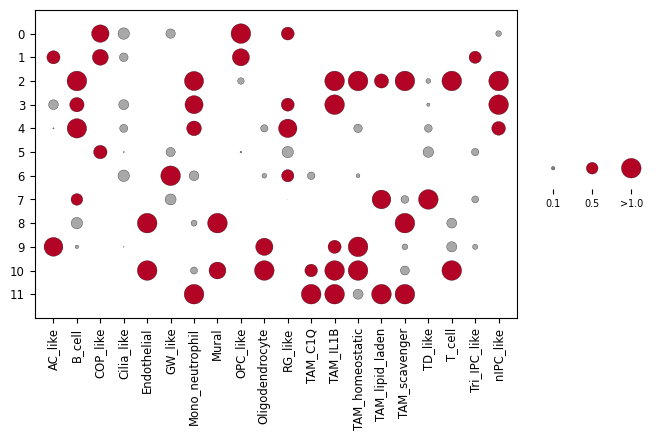

In [ ]:
cc.pl.enrichment(
    adata,
    group_key='tangram_prediction',
    label_key='cluster_cellcharter',
    cluster_labels=False,
    # labels = [16, 1, 17, 2, 14, 9, 5, 6, 10, 7, 8, 11, 13, 19, 18, 0, 12, 4, 3, 15],
    figsize=(8, 4),
    size_threshold=1,
    color_threshold=0.5
)

In [ ]:
gmm = cc.tl.Cluster(
    n_clusters=9, 
    random_state=12345,
    # If running on GPU
    trainer_params=dict(accelerator='gpu', devices=1)
)

In [ ]:
gmm.fit(adata, use_rep='X_cellcharter')
adata.obs['cellcharter_9'] = gmm.predict(adata, use_rep='X_cellcharter')

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/cruiz2/miniconda3/envs/cellcharter/lib/pyt ...
  rank_zero_warn(


In [ ]:
adata.obs['PMCID_FOV'] = adata.obs.PMCID.astype(str) + '_' + adata.obs.FOV.astype(str)
adata.obs['PMCID_FOV'] = adata.obs['PMCID_FOV'].astype('category')

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:757: RuntimeWarning: invalid value encountered in power
  size = frac**size_exponent


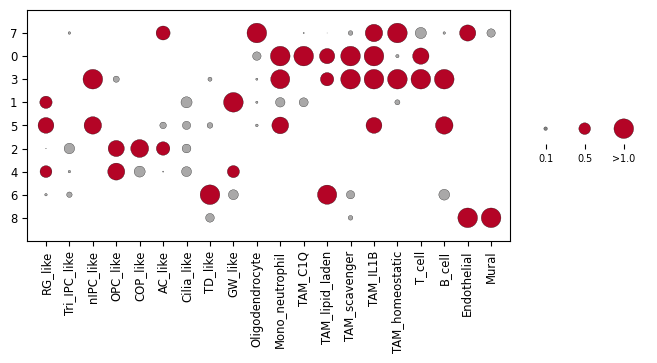

In [ ]:
cc.gr.enrichment(adata, group_key='tangram_prediction', label_key='cellcharter_9', observed_expected=True)
cc.pl.enrichment(
    adata,
    group_key='tangram_prediction',
    label_key='cellcharter_9',
    cluster_labels=True,
    figsize=(8, 3),
    size_threshold=1,
    color_threshold=0.5
)

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:757: RuntimeWarning: invalid value encountered in power
  size = frac**size_exponent


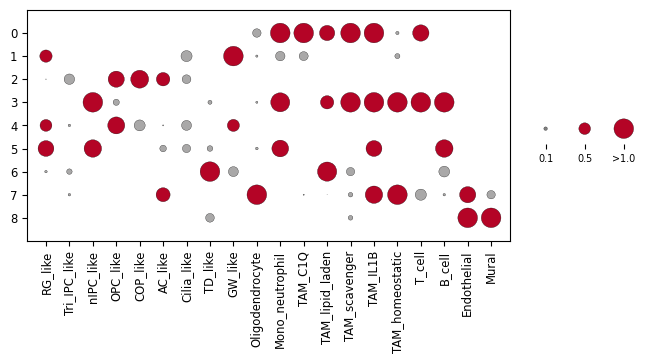

In [ ]:
# cc.gr.enrichment(adata, group_key='tangram_prediction', label_key='cellcharter_9', observed_expected=True)
cc.pl.enrichment(
    adata,
    group_key='tangram_prediction',
    label_key='cellcharter_9',
    cluster_labels=False,
    figsize=(8, 3),
    size_threshold=1,
    color_threshold=0.5,
    save='figures/enrichment_cellcharter_celltype_vs_niche.pdf'
)

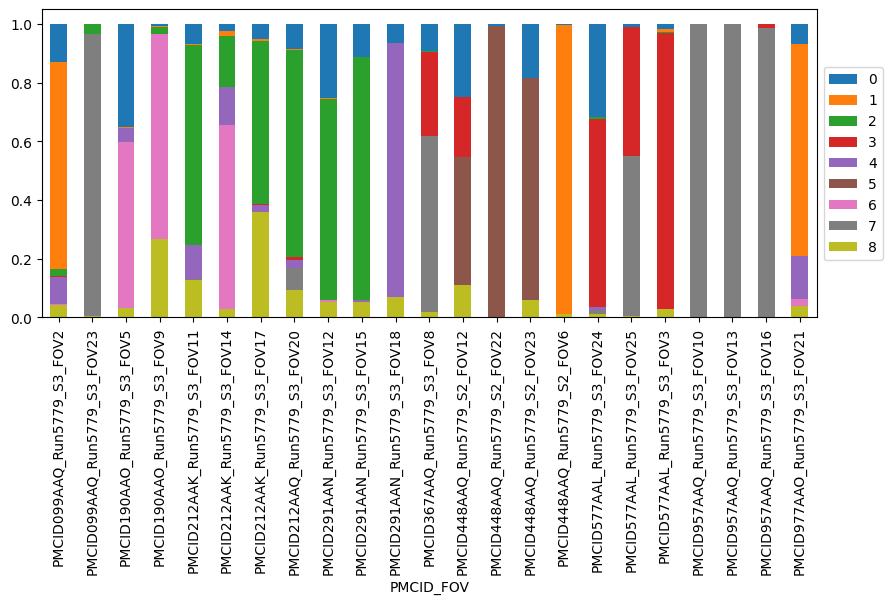

In [ ]:
adata.obs['PMCID_FOV'] = adata.obs.PMCID.astype(str) + '_' + adata.obs.FOV.astype(str)
adata.obs['PMCID_FOV'] = adata.obs['PMCID_FOV'].astype('category')
cc.pl.proportion(
    adata,
    group_key='PMCID_FOV',
    label_key='cellcharter_9',
    figsize=(10, 4),
    rotation_xlabel=90,
        save='figures/cellcharter_9niches_cosmx.pdf'
)

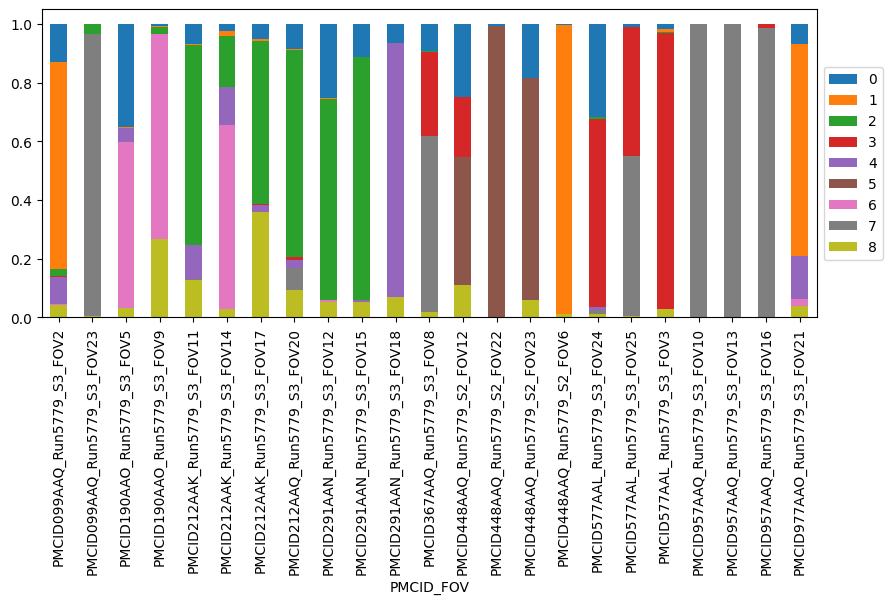

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from cellcharter.pl import proportion

# Set the pdf.fonttype to 42 to embed fonts as Type 42 (TrueType)
mpl.rcParams['pdf.fonttype'] = 42

# Create the plot
proportion(adata,
    group_key='PMCID_FOV',
    label_key='cellcharter_9',
    figsize=(10, 4),
    rotation_xlabel=90,
           save=None)

# Save the plot as PDF with embedded fonts
plt.savefig('figures/cellcharter_9niches_cosmx.pdf', format='pdf', bbox_inches='tight')